In [1]:
import os
import re
import sys
from collections import defaultdict
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

try:
    from nltk import sent_tokenize as _nltk_sent_tokenize
    from nltk import word_tokenize as _nltk_word_tokenize

    _nltk_sent_tokenize("test sentence.")
    _nltk_word_tokenize("test sentence.")
    sent_tokenize = _nltk_sent_tokenize
    word_tokenize = _nltk_word_tokenize
    print("使用 NLTK 分词")
except (ImportError, LookupError):
    print("使用本地正则分词")

    def sent_tokenize(text):
        return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

    def word_tokenize(sentence):
        return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|[0-9]+|[^\w\s]", sentence)


使用本地正则分词


In [2]:
class TextDataset:
    def __init__(self, file_path, tokenize=True):
        # 读取文本并按需进行分词
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        if tokenize:
            self.sentences = sent_tokenize(text.lower())
            self.tokens = [word_tokenize(sent) for sent in self.sentences]
        else:
            self.text = text

    def build_vocab(self, min_freq=1):
        # 统计词频
        frequency = defaultdict(int)
        for sentence in self.tokens:
            for token in sentence:
                frequency[token] += 1
        self.frequency = frequency

        # 加入<unk>处理未登录词，加入<pad>用于对齐变长输入进而加速
        self.token2id = {'<unk>': 1, '<pad>': 0}
        self.id2token = {1: '<unk>', 0: '<pad>'}
        for token, freq in sorted(frequency.items(), key=lambda x: -x[1]):
            # 丢弃低频词
            if freq > min_freq:
                self.token2id[token] = len(self.token2id)
                self.id2token[len(self.id2token)] = token
            else:
                break

    def get_word_distribution(self):
        distribution = np.zeros(len(self.token2id))
        for token, freq in self.frequency.items():
            token_id = self.token2id.get(token, self.token2id['<unk>'])
            distribution[token_id] += freq
        distribution /= distribution.sum()
        return distribution

    # 将分词结果转化为索引表示
    def convert_tokens_to_ids(self, drop_single_word=True):
        self.token_ids = []
        for sentence in self.tokens:
            token_ids = [self.token2id.get(token, 1) for token in sentence]
            # 忽略只有一个token的序列，无法计算loss
            if len(token_ids) == 1 and drop_single_word:
                continue
            self.token_ids.append(token_ids)
        return self.token_ids


234


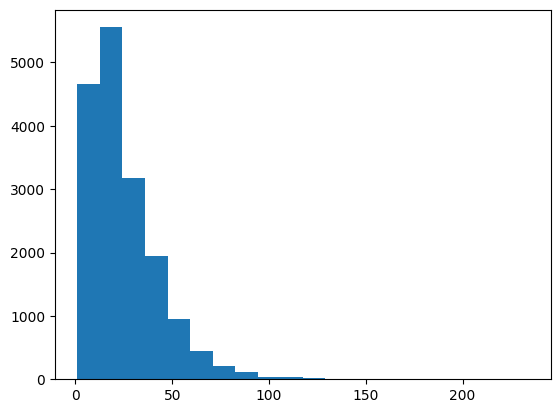

In [3]:
from pathlib import Path

file_path = Path(r"D:\DeepLearning\DataSet\Text\anna.txt")

dataset = TextDataset(file_path=file_path)

# 统计每句话的长度
sent_lens = [len(sentence) for sentence in dataset.tokens]
max_len = max(sent_lens)
print(max_len)

plt.hist(sent_lens, bins=20)
plt.show()

接下来建立词表，截断过长的序列，将序列填充（padding）到相同长度（不使用词嵌入）

In [4]:
import numpy as np

dataset.build_vocab()
sent_tokens = dataset.convert_tokens_to_ids()
# 截断和填充
max_len=40
for i, tokens in enumerate(sent_tokens):
    tokens = tokens[:max_len]
    tokens += [dataset.token2id['<pad>']] * (max_len - len(tokens))
    sent_tokens[i] = tokens
sent_tokens = np.array(sent_tokens)

print(len(dataset.tokens), max([len(x) for x in dataset.tokens]))
print(sent_tokens.shape)
print(sent_tokens[0])

17190 234
(17186, 40)
[ 204  681  285 3079   79   32 2499   36  201  700  367   39  700   11
  234  145  161    3    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


In [5]:
# 定义一个正态分布的函数用于初始化参数
def normal(shape):
    return torch.randn(size=shape) * 0.01

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # 将输入与隐状态分别经过线性变化后相加
        self.W_xh = nn.Parameter(normal((input_size, hidden_size)))
        self.W_hh = nn.Parameter(normal((hidden_size, hidden_size)))
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
    
    def init_rnn_state(self, batch_size, hidden_size):
        return (torch.zeros((batch_size, hidden_size), dtype=torch.float, device=self.W_xh.device),)
    
    def forward(self, inputs, states):
        seq_len, batch_size, _ = inputs.shape
        hidden_state, = states
        hiddens = []
        for step in range(seq_len):
            # 输入hidden_state与inputs经过线性变换后相加，
            # 输出的hidden_state也是下一时刻输入的hidden_state
            xh = torch.mm(inputs[step], self.W_xh)
            hh = torch.mm(hidden_state, self.W_hh)
            hidden_state = xh + hh + self.b_h
            hidden_state = torch.tanh(hidden_state)
            hiddens.append(hidden_state)
        # 返回所有时刻的hidden_state: seq_len * batch_size * hidden_size
        # 以及最后时刻的hidden_state 
        # batch_size * hidden_size
        return torch.stack(hiddens, dim=0), (hidden_state,)

# 在循环神经网络的基础上添加语言模型的输入输出、损失计算等
class RNNLM(nn.Module):
    def __init__(self, model, vocab_size, hidden_size):
        super(RNNLM, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.model = model
        self.W_hq = nn.Parameter(normal((hidden_size, vocab_size)))
        self.b_q = nn.Parameter(torch.zeros(vocab_size))
        
    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        # input_ids形状为batch_size * seq_len，翻转为seq_len * batch_size，
        # 将seq_len放在第一维方便计算
        input_ids = torch.permute(input_ids, (1, 0))
        # seq_len * batch_size * embed_size
        embed = self.embedding(input_ids)
        # batch_size * hidden_size
        states = self.model.init_rnn_state(batch_size, self.hidden_size)
        hiddens, _ = self.model(embed, states)
    
        hiddens = torch.flatten(hiddens[:-1], start_dim=0, end_dim=1)
        output_states = torch.mm(hiddens, self.W_hq) + self.b_q
        labels = torch.flatten(input_ids[1:], start_dim=0, end_dim=1)
        loss_fct = nn.CrossEntropyLoss(ignore_index=0)
        loss = loss_fct(output_states, labels)
        return loss

下面展示使用梯度裁剪的循环神经网络语言模型的训练代码。

In [ ]:
# 是否可用 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'当前使用设备: {device}')

# 梯度裁剪
def grad_clipping(model, theta=1):
    params = [p for p in model.parameters() if p.requires_grad and p.grad is not None]
    if not params:
        return
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm
    

# 训练
from torch.utils.data import DataLoader
from torch.optim import SGD, Adam
from tqdm import tqdm, trange


def train_rnn_lm(data_loader, rnn, vocab_size, hidden_size=128,
                 epochs=200, learning_rate=1e-3):
    # 准备模型、优化器等
    rnn_lm = RNNLM(rnn, vocab_size, hidden_size).to(device)
    optimizer = Adam(rnn_lm.parameters(), lr=learning_rate)
    rnn_lm.zero_grad()
    rnn_lm.train()

    epoch_loss = []
    with trange(epochs, desc='epoch', ncols=60) as pbar:
        for epoch in pbar:
            for step, batch in enumerate(data_loader):
                batch = batch.to(device)
                loss = rnn_lm(batch)
                pbar.set_description(f'epoch: {epoch}, ' +
                    f'loss={loss.item():.4f}')
                loss.backward()
                grad_clipping(rnn_lm)
                optimizer.step()
                rnn_lm.zero_grad()
            epoch_loss.append(loss.item())

    epoch_loss = np.array(epoch_loss)
    # 打印损失曲线
    plt.plot(range(len(epoch_loss)), epoch_loss)
    plt.xlabel('training epoch')
    plt.ylabel('loss')
    plt.show()

sent_tokens = np.array(sent_tokens)
print(sent_tokens.shape)
vocab_size = len(dataset.token2id)

data_loader = DataLoader(torch.tensor(sent_tokens, dtype=torch.long),
    batch_size=16, shuffle=True)


当前使用设备: cuda
(17186, 40)


In [7]:
rnn = RNN(128, 128).to(device)
train_rnn_lm(data_loader, rnn, vocab_size, hidden_size=128,
    epochs=200, learning_rate=1e-3)

epoch-1, loss=4.4750:   0%| | 1/200 [00:21<1:10:50, 21.36s/i


KeyboardInterrupt: 

**LSTM**

In [10]:
# 长短期记忆
def gate_params(input_size, hidden_size):
    return (nn.Parameter(normal((input_size, hidden_size))),
           nn.Parameter(normal((hidden_size, hidden_size))),
           nn.Parameter(torch.zeros(hidden_size)))

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # 输入门参数
        self.W_xi, self.W_hi, self.b_i = gate_params(input_size, hidden_size)
        # 遗忘门参数
        self.W_xf, self.W_hf, self.b_f = gate_params(input_size, hidden_size)
        # 输出门参数
        self.W_xo, self.W_ho, self.b_o = gate_params(input_size, hidden_size)
        # 候选记忆单元参数
        self.W_xc, self.W_hc, self.b_c = gate_params(input_size, hidden_size)
        
    def init_rnn_state(self, batch_size, hidden_size):
        device = self.W_xi.device
        dtype = self.W_xi.dtype
        return (
            torch.zeros((batch_size, hidden_size), dtype=dtype, device=device),
            torch.zeros((batch_size, hidden_size), dtype=dtype, device=device),
        )
    
    def forward(self, inputs, states):
        seq_len, batch_size, _ = inputs.shape
        hidden_state, cell_state = states
        hiddens = []
        for step in range(seq_len):
            I = torch.sigmoid(torch.mm(inputs[step], self.W_xi) \
                + torch.mm(hidden_state, self.W_hi) + self.b_i)
            F = torch.sigmoid(torch.mm(inputs[step], self.W_xf) \
                + torch.mm(hidden_state, self.W_hf) + self.b_f)
            O = torch.sigmoid(torch.mm(inputs[step], self.W_xo) \
                + torch.mm(hidden_state, self.W_ho) + self.b_o)
            C_tilda = torch.tanh(torch.mm(inputs[step], self.W_xc) \
                + torch.mm(hidden_state, self.W_hc) + self.b_c)
            cell_state = F * cell_state + I * C_tilda
            hidden_state = O * torch.tanh(cell_state)
            hiddens.append(hidden_state)
        return torch.stack(hiddens, dim=0), (hidden_state, cell_state)


In [11]:
lstm = LSTM(128, 128).to(device)

train_rnn_lm(data_loader, lstm, vocab_size, hidden_size=128, epochs=200, learning_rate=1e-3)

epoch-9, loss=3.9739:   4%| | 9/200 [09:58<3:31:35, 66.47s/i


KeyboardInterrupt: 